# Using Plotly

In [1]:
def get_data(city, counter_name):
    """Fetch data for a given city and counter site.

    Args:
        city (str): Name of the city, written as in weather file names.
        counter_name (str): Counter site of interest.
        
    Returns:
        pd.DataFrame: Merged DataFrame with bike counts, rain, and temperature.
    """  
    import pandas as pd
    import plotly.express as px
    from get_table import get_bike_table
    from get_table import get_table_with_weather
    
    df_common = get_table_with_weather(city, counter_name, 2024, 11, 1, 2025, 10, 31)
    
    return df_common

## Notes
- I used `pd.merge` to keep all datetimes, not only the common ones. This is more reasonable for plotting, as we can now see where we're missing which data.
- How to interact with the plots: 
  - hover vertically to see bike count, temperature, and rain of a specific datetime
  - use rangeslider to zoom in
  - double click to zoom out completely 
  - click on variable to show/hide the line in the plot
- Counter sites for Heidelberg and Mannheim are arbitrarily picked, we should think about which sites are useful (or combine various) 

In [2]:
def plot_bike_and_weather(city, counter_name):
    """Fetch data for a given city and counter site, merge bike counts with weather data, and create an interactive plot.

    Args:
        city (str): Name of the city, written as in weather file names.
        counter_name (str): Counter site of interest.
    """
    import plotly.express as px
    
    df_common = get_data(city, counter_name)
    
    fig = px.line(df_common, x="datetime", y=df_common.columns,
                  category_orders={"variable": ["bike", "rain", "temp"]},
                  color_discrete_map={    # Custom colors
                    "bike": px.colors.qualitative.Set3[0],
                    "temp": px.colors.qualitative.Set3[3],
                    "rain": px.colors.qualitative.Set3[4],
                    },
                  title=f"Bike Counts and Weather Data for {city}, {counter_name}")

    fig.update_layout(hovermode="x unified")        # On hover, show all values depending on x axis together
    fig.update_traces(hovertemplate=None)           # Compact hover info

    fig.update_xaxes(rangeslider_visible=True)      # Add range slider

    fig.show()


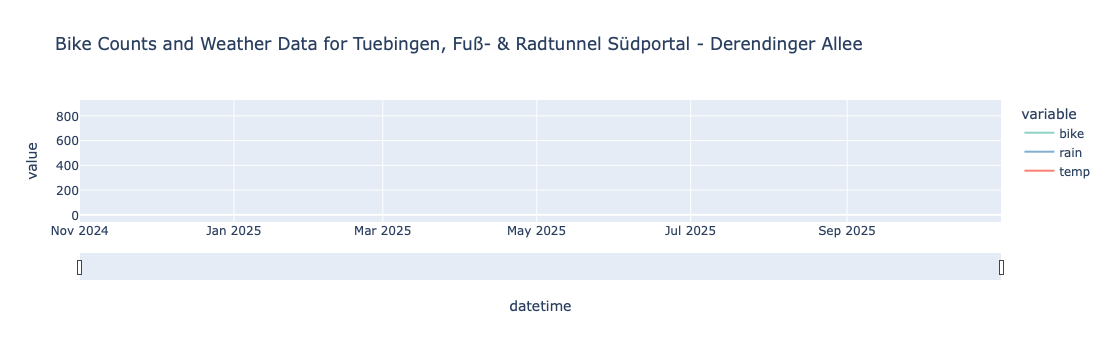

In [3]:
plot_bike_and_weather("Tuebingen", "Fuß- & Radtunnel Südportal - Derendinger Allee")

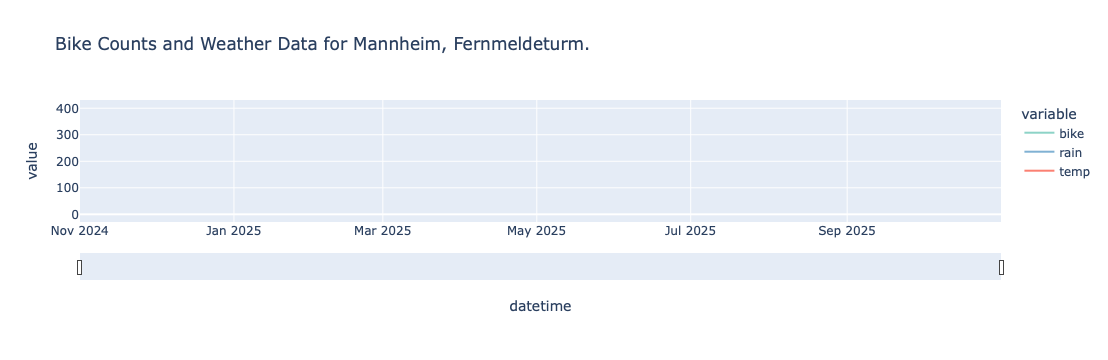

In [4]:
plot_bike_and_weather("Mannheim", "Fernmeldeturm.")

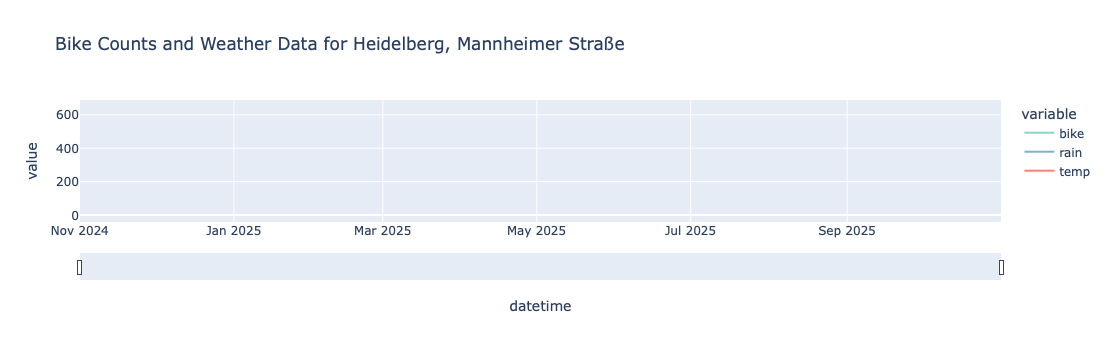

In [5]:
plot_bike_and_weather("Heidelberg", "Mannheimer Straße")

Interesting to see here: the spike on August 22 – August 24 is probably the "Street Food & Music Festival Heidelberg" which took place on the "Messplatz", which is very close to the counter at Mannheimer Straße. 

## Use graph opjects to have multiple y-axes

In [6]:
def plot_data_overlay(city, counter_name):
    """Fetch data for a given city and counter site, merge bike counts with weather data, and create an interactive plot.

    Args:
        city (str): Name of the city, written as in weather file names.
        counter_name (str): Counter site of interest.
    """    
    import pandas as pd
    import plotly.graph_objects as go
    import plotly.express as px
    from get_table import get_table
    
    df_common = get_data(city, counter_name)
    
    fig = go.Figure()
    
    # Bike trace
    fig.add_trace(go.Scatter(
        x=df_common['datetime'],
        y=df_common['bike'],
        name='Bike Count',
        line=dict(color=px.colors.qualitative.Set3[0]),
        yaxis='y1'
    ))
    # Temperature trace
    fig.add_trace(go.Scatter(
        x=df_common['datetime'],
        y=df_common['temp'],
        name='Temperature',
        line=dict(color=px.colors.qualitative.Set3[3]),
        yaxis='y2'
    ))
    # Rain trace
    fig.add_trace(go.Scatter(
        x=df_common['datetime'],
        y=df_common['rain'],
        name='Rainfall',
        line=dict(color=px.colors.qualitative.Set3[4]),
        yaxis='y3'
    ))
    
    
    # Layout for multiple y-axes
    fig.update_layout(
        title=f"Bike Counts and Weather Data for {city}, {counter_name}",
        
        legend={
            "y": 1.5,
        },
        
        xaxis=dict(
            title='Datetime',
            rangeslider=dict(visible=True),
            #domain=[0.25, 0.75]
        ),
        
        yaxis=dict(
            title=dict(
                text="Bike Count [#]",
                font=dict(
                    color=px.colors.qualitative.Set3[0]
                ),
            ),
            side='left',
            showgrid=False
        ),
        yaxis2=dict(
            title=dict(
                text="Temperature [°C]",
                font=dict(
                    color=px.colors.qualitative.Set3[3]
                ),
            ),
            anchor="x",
            overlaying="y",
            side="right",
            showgrid=False,
        ),
        yaxis3=dict(
            title=dict(
                text="Rainfall [mm]",
                font=dict(
                    color=px.colors.qualitative.Set3[4]
                ),
            ),
            anchor="free",
            overlaying="y",
            side="right",
            autoshift=True,
            showgrid=False,
            shift=50,
        ),
        hovermode='x unified',
    )

    fig.show()


In [7]:
plot_data_overlay("Tuebingen", "Fuß- & Radtunnel Südportal - Derendinger Allee")

In [8]:
plot_data_overlay("Mannheim", "Fernmeldeturm.")

In [9]:
plot_data_overlay("Heidelberg", "Mannheimer Straße")

# Fourier Analysis for Tuebingen

How to understand the code and interpret the plots: 

We perform the fast fourier transformation (FFT) on the data and receive `fft_values` (here $Y$). 

For real-valued signals, the FFT contains both positive frequency components and mirror-image negative frequency components, each contributes half the energy. 
We drop the negative side to receive the usual single-sided spectrum. Therefore, we must double the positive side to get the true amplitude. Dividing by N just normalizes the FFT. 

This results in `amplitudes` = $\frac{2}{N} |Y[k]|$ containing the actual amplitude of the sinusoid at frequency $k$. Therefore, it tells us how big the daily, weekly, yearly oscillation actually is, in original measurement units (°C, mm, etc.). E.g. the amplitude for temperature in Tuebingen at the yearly frequency is 9.4, this means that the temperature oscillates $\pm$ 9.4°C around the annual mean. This is the half of the peak-to-peak seasonal swing: 2 $\cdot$ 9.4°C = 18.8°C $\Rightarrow$ there is an 18.8°C swing from winter to summer. This aligns well with reality. 

Bike counts have a daily swing of about 190. This can be interpreted like this: There are 380 bikes more counted during the day than during the night. The actual values are obviously again a composition of all frequencies. 

In [42]:
def plot_fourier_transform(df, title='Fourier Transform'):
    import plotly.graph_objects as go
    from scipy.fft import fft, fftfreq
    import numpy as np  
    
    # prepare data for FFT
    fourier_data = df.fillna(0)                             # Fill NaNs with 0
    fourier_data = fourier_data.to_numpy()                  # Convert to numpy array
    fourier_data = fourier_data - np.mean(fourier_data)     # Detrend by removing mean (important! otherwise huge peak at 0 Hz)
    
    N = len(fourier_data)
    T = 1.0                                             # Hourly data, so the sample spacing is 1 hour
    frequencies = fftfreq(N, T)[:N//2]                  # Frequency bins (only positive frequencies)  
    fft_values = fft(fourier_data)                      # Perform FFT
    amplitudes = 2.0/N * np.abs(fft_values[0:N//2])     # Amplitude spectrum
    
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=frequencies,
        y=amplitudes,
        mode='lines',
        name='FFT Amplitude'
    ))
    fig.update_layout(
        title=title,
        xaxis_title='Frequency (1/hour)',
        yaxis_title='Amplitude',
        hovermode='x unified'
    )
    
    # add vertical lines for yearly, weekly, daily, ... cycles
    yearly_freq = 1 / (365 * 24)    # yearly cycle frequency
    weekly_freq = 1 / (7 * 24)      # weekly cycle frequency
    weekday_freq = 2 / (7 * 24)     # weekday-weekend asymmetry cycle frequency
    daily_freq = 1 / 24             # daily cycle frequency
    h_12_freq = 1 / 12              # 1/2 day = 12 hour cycle frequency 
    h_8_freq = 1 / 8                # 1/3 day = 8 hour cycle frequency
    h_6_freq = 1 / 6                # 1/4 day = 6 hour cycle frequency
    h_4_8_freq = 1 / 4.8            # 1/5 day = 4.8 hour cycle frequency
    h_4_freq = 1 / 4                # 1/6 day = 4 hour cycle frequency
    fig.add_vline(x=yearly_freq, line_dash="dash", line_width=1,
                  annotation_text="Yearly", annotation_position="top left")
    fig.add_vline(x=weekly_freq, line_dash="dash", line_width=1,
                  annotation_text="Weekly", annotation_position="top")
    fig.add_vline(x=weekday_freq, line_dash="dash", line_width=1,
                  annotation_text="Weekend", annotation_position="top right")
    fig.add_vline(x=daily_freq, line_dash="dash", line_width=1, 
                  annotation_text="Daily", annotation_position="top")
    fig.add_vline(x=h_12_freq, line_dash="dash", line_width=1,
                  annotation_text="12h", annotation_position="top left")
    fig.add_vline(x=h_8_freq, line_dash="dash", line_width=1,
                  annotation_text="8h", annotation_position="top left")
    fig.add_vline(x=h_6_freq, line_dash="dash", line_width=1,
                  annotation_text="6h", annotation_position="top left")
    fig.add_vline(x=h_4_8_freq, line_dash="dash", line_width=1,
                    annotation_text="4.8h", annotation_position="top left")
    fig.add_vline(x=h_4_freq, line_dash="dash", line_width=1,
                  annotation_text="4h", annotation_position="top left") 
    
    # add range slider
    fig.update_xaxes(rangeslider_visible=True)
    
    fig.show()
    


Define variables to only fetch data once. This may take a bit.

In [35]:
tue_df = get_data("Tuebingen", "Fuß- & Radtunnel Südportal - Derendinger Allee")
hd_df = get_data("Heidelberg", "Mannheimer Straße")
ma_df = get_data("Mannheim", "Fernmeldeturm.")

tue_bike, tue_temp, tue_rain = tue_df['bike'], tue_df['temp'], tue_df['rain']
hd_bike, hd_temp, hd_rain = hd_df['bike'], hd_df['temp'], hd_df['rain']
ma_bike, ma_temp, ma_rain = ma_df['bike'], ma_df['temp'], ma_df['rain']

In [43]:
plot_fourier_transform(tue_bike, title='Fourier Transform of Bike Counts for Tuebingen')
plot_fourier_transform(hd_bike, title='Fourier Transform of Bike Counts for Heidelberg')
plot_fourier_transform(ma_bike, title='Fourier Transform of Bike Counts for Mannheim')

Very clear daily cycles, also weekly and fractions of the day are visibly present. The yearly frequency is not too dominant, but that might be due to only considering one year of data. 

What we would expect: 
- The strongest FFT peak should be at 1 cycle/day, reflecting the main daily pattern, with amplitude roughly equal to half the typical peak-to-trough difference $\checkmark$ 
- The second harmonic at 2 cycles/day should appear with a smaller amplitude, capturing the distinct morning and evening rush peaks $\checkmark$ 
- Weaker higher harmonics (3–5/day) should also appear but with decreasing amplitude. They encode sharper features in traffic $\checkmark$ 
- There should also be a small peak at 1/7 cycles/day reflecting weekly differences between weekdays and weekends $\checkmark$ 
- There will probably be a smaller peak at the second harmonic in the weekly cycle, due to weekday patterns differing from weekend patterns in a structured way (5 days vs 2 days) $\checkmark$

In [44]:
plot_fourier_transform(tue_temp, title='Fourier Transform of Temperature for Tuebingen')
plot_fourier_transform(hd_temp, title='Fourier Transform of Temperature for Heidelberg')
plot_fourier_transform(ma_temp, title='Fourier Transform of Temperature for Mannheim')

Mainly yearly and also clearly daily frequencies. The 12h cycle is also visible, but the arbitrary fractions of the day not. Seems reasonable. 

Temperature is smooth, so the signal is almost sinusoidal. This means, that higher harmonics are very small. \
Bike counts are spiky with sharp rush-hour peaks. This means, that higher harmonics are large and visible.

In [45]:
plot_fourier_transform(tue_rain, title='Fourier Transform of Rainfall for Tuebingen')
plot_fourier_transform(hd_rain, title='Fourier Transform of Rainfall for Heidelberg')
plot_fourier_transform(ma_rain, title='Fourier Transform of Rainfall for Mannheim')

Not really a pettern (as expected).